# Smartphone ML Intelligence

## 02 — Exploratory Data Analysis

### Objectives

- Understand the smartphone market represented in the dataset
- Analyse brand and price-segment distribution
- Explore relationships between hardware specifications, price, and performance
- Identify important correlations and potential outliers
- Generate insights that will guide feature engineering and ML modelling

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42

In [3]:
DATA_PATH = Path("../data/processed/phones_clean.csv")

phones = pd.read_csv(
    DATA_PATH,
    parse_dates=["launch_date"]
)

print(f"Rows: {phones.shape[0]}")
print(f"Columns: {phones.shape[1]}")

phones.head()

Rows: 270
Columns: 47


,name,brand,sale,processor_type,processor,fab,ram_type,rom_type,display_type,size,curved_display,refresh_rate,hbm,protection,ppi,battery,charging_speed,thickness,back_material,frame_material,weight,launch_date,camera_number,useful_camera_number,main,camera_sensor_name,ultrawide,third,third_mp,fourth,fourth_mp,rear_video,front,front_video,colors,antutu,geekbench_single,geekbench_multiple,speaker,wireless_charging,ip_rating,price,has_ultrawide,has_third_camera,has_fourth_camera,launch_year,phone_age_days
0,CMF Phone 1,Nothing,Online,Mediatek,Dimensity 7300,4,LPDDR4X,UFS 2.2,Amoled,6.67,False,120,NaN,NaN,395,5000,33,8.2,Plastic,Plastic,202,2024-07-08,2,1,50,NaN,NaN,Useless,2.0,NaN,NaN,"4, 30",16.0,"4, 30",3,646635,1013,2949,Mono,False,52,16000,False,True,False,2024,792
1,CMF Phone 2 Pro,Nothing,Online,Mediatek,Dimensity 7300,4,LPDDR4X,UFS 2.2,Amoled,6.77,False,120,1300.0,"Panda Glass,",388,5000,33,7.8,Plastic,Plastic,185,2025-05-28,3,3,50,NaN,8.0,Telephoto - 2x,50.0,NaN,NaN,"4, 30",16.0,"4, 30",4,704101,1013,2936,Mono,False,54,19000,True,True,False,2025,468
2,Galaxy A07,Samsung,Offline,Mediatek,Dimensity 6300,6,LPDDR4X,UFS 2.2,IPS LCD,6.70,False,120,800.0,NaN,262,6000,25,8.2,Plastic,Plastic,199,2026-02-05,2,1,50,NaN,NaN,Useless,2.0,NaN,NaN,"1, 60",8.0,"1, 30",2,450401,731,2012,Mono,False,54,20000,False,True,False,2026,215
3,Galaxy A17,Samsung,Offline,Exynos,1330,5,LPDDR4X,UFS 2.2,Amoled,6.70,False,90,800.0,"Corning, GG Victus",358,5000,25,7.5,Plastic,Plastic,193,2025-08-29,3,2,50,NaN,5.0,Useless,2.0,NaN,NaN,"1, 30",13.0,"1, 30",3,473905,942,2137,Mono,False,54,28000,True,True,False,2025,375
4,Galaxy A27,Samsung,Offline,Snapdragon,6 Gen 3,4,LPDDR5X,UFS 3.1,Amoled,6.70,False,120,800.0,"Corning, GG Victus +",385,5000,25,7.8,Glass,Plastic,200,2026-06-25,2,2,50,NaN,5.0,Useless,2.0,NaN,NaN,"4, 30",12.0,"1, 30",3,892500,1080,3192,Mono,False,64,34000,True,True,False,2026,75


In [4]:
phones.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
name,270,270,CMF Phone 1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,270,15,Samsung,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sale,270,4,Online,108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
processor_type,270,6,Mediatek,118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
processor,270,75,Dimensity 6300,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fab,270.0,NaN,NaN,NaN,4.244444,2.0,4.0,4.0,4.0,6.0,1.038061
ram_type,270,3,LPDDR4X,135,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rom_type,270,5,UFS 2.2,114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
display_type,270,2,Amoled,213,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size,270.0,NaN,NaN,NaN,6.691889,6.1,6.67,6.74,6.78,7.0,0.16997


## 1. Market composition by brand

In [5]:
brand_counts = (
    phones["brand"]
    .value_counts()
    .sort_values(ascending=False)
)

brand_counts



brand
Samsung     28
Xiaomi      28
Motorola    26
Vivo        25
Realme      25
Oppo        25
OnePlus     20
POCO        16
IQOO        15
Apple       14
Nothing     13
Lava        11
Tecno       10
Google       8
Infinix      6
Name: count, dtype: int64

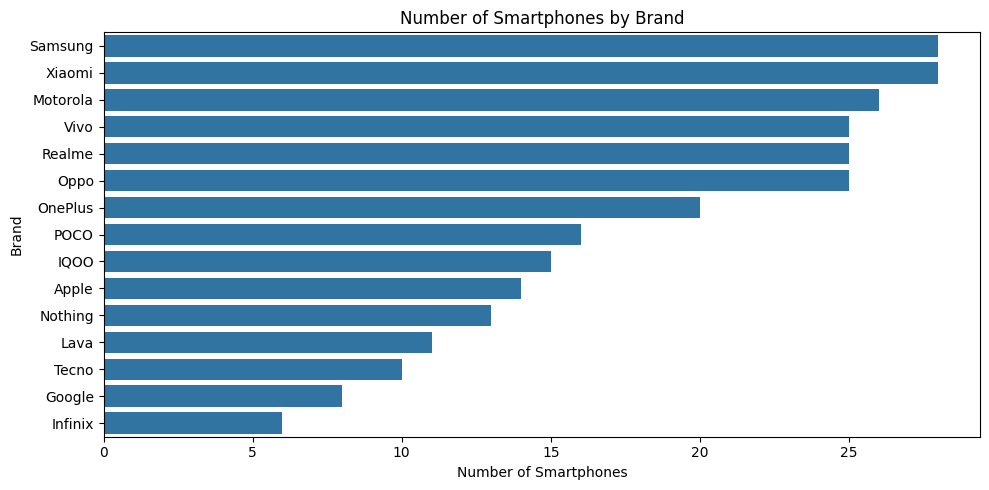

In [6]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=brand_counts.values,
    y=brand_counts.index
)

plt.title("Number of Smartphones by Brand")
plt.xlabel("Number of Smartphones")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

## 2. Smartphone price distribution

In [7]:
phones["price"].describe()

count       270.000000
mean      43545.555556
std       32773.703625
min        9000.000000
25%       22250.000000
50%       30000.000000
75%       55000.000000
max      170000.000000
Name: price, dtype: float64

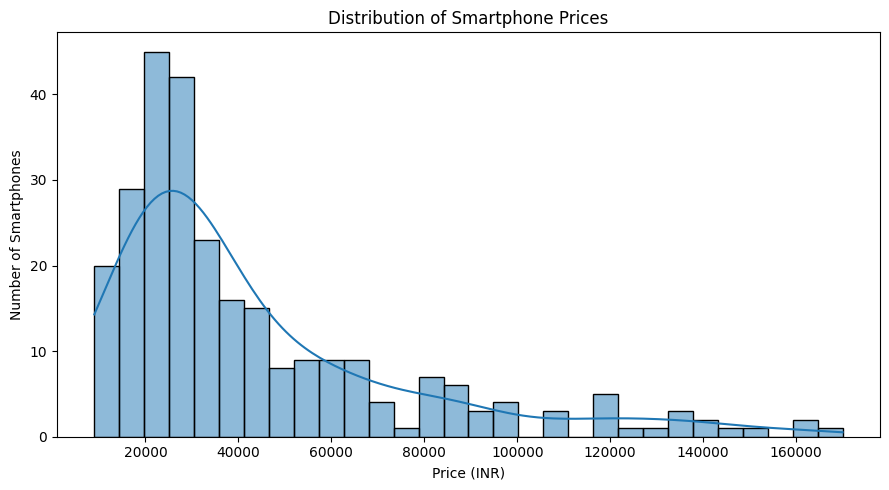

In [8]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=phones,
    x="price",
    bins=30,
    kde=True
)

plt.title("Distribution of Smartphone Prices")
plt.xlabel("Price (INR)")
plt.ylabel("Number of Smartphones")
plt.tight_layout()
plt.show()

In [9]:
def assign_price_segment(price):
    if price < 20_000:
        return "Budget"
    elif price < 40_000:
        return "Mid-range"
    elif price < 70_000:
        return "Premium"
    else:
        return "Flagship"


phones["price_segment"] = phones["price"].apply(
    assign_price_segment
)

phones["price_segment"].value_counts()

segment_order = [
    "Budget",
    "Mid-range",
    "Premium",
    "Flagship"
]

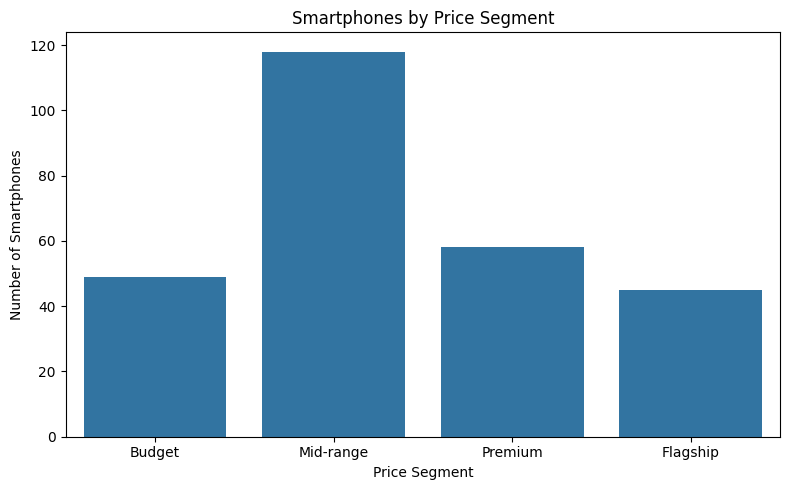

In [10]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=phones,
    x="price_segment",
    order=segment_order
)

plt.title("Smartphones by Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Number of Smartphones")
plt.tight_layout()
plt.show()

In [11]:
brand_price_summary = (
    phones
    .groupby("brand")
    .agg(
        phone_count=("name", "count"),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
        min_price=("price", "min"),
        max_price=("price", "max")
    )
    .sort_values(
        "median_price",
        ascending=False
    )
)

brand_price_summary

,phone_count,median_price,mean_price,min_price,max_price
brand,,,,,
Apple,14,104950.0,108057.142857,60000,160000
Google,8,100000.0,95750.000000,50000,135000
Oppo,25,42000.0,53180.000000,12500,170000
Vivo,25,40000.0,52400.000000,17000,160000
Samsung,28,35250.0,52642.857143,18500,140000
OnePlus,20,33500.0,39850.000000,20000,86000
Nothing,13,30000.0,36000.000000,16000,80000
Realme,25,30000.0,33400.000000,20000,73000
IQOO,15,29000.0,36100.000000,10000,86000


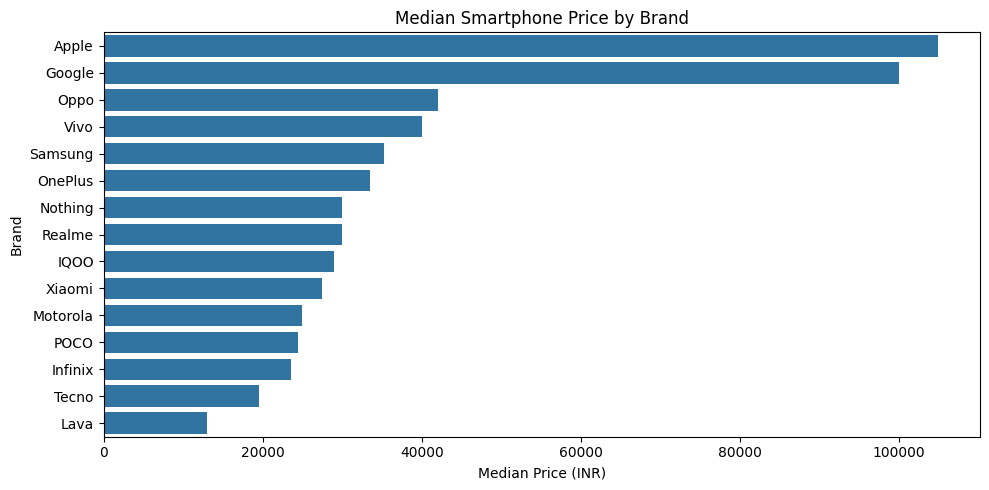

In [12]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=brand_price_summary.reset_index(),
    x="median_price",
    y="brand"
)

plt.title("Median Smartphone Price by Brand")
plt.xlabel("Median Price (INR)")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

In [13]:
brand_segment_table = pd.crosstab(
    phones["brand"],
    phones["price_segment"]
)

brand_segment_table

price_segment,Budget,Flagship,Mid-range,Premium
brand,,,,
Apple,0,12,0,2
Google,0,6,0,2
IQOO,3,1,7,4
Infinix,2,0,4,0
Lava,10,0,1,0
Motorola,9,0,13,4
Nothing,2,1,6,4
OnePlus,0,2,12,6
Oppo,3,6,7,9


In [14]:
brand_segment_pct = pd.crosstab(
    phones["brand"],
    phones["price_segment"],
    normalize="index"
) * 100

brand_segment_pct.round(1)

price_segment,Budget,Flagship,Mid-range,Premium
brand,,,,
Apple,0.0,85.7,0.0,14.3
Google,0.0,75.0,0.0,25.0
IQOO,20.0,6.7,46.7,26.7
Infinix,33.3,0.0,66.7,0.0
Lava,90.9,0.0,9.1,0.0
Motorola,34.6,0.0,50.0,15.4
Nothing,15.4,7.7,46.2,30.8
OnePlus,0.0,10.0,60.0,30.0
Oppo,12.0,24.0,28.0,36.0


## 3. Performance analysis

In [15]:
phones["antutu"].describe()

count    2.700000e+02
mean     1.274367e+06
std      8.966118e+05
min      3.411050e+05
25%      6.278582e+05
50%      8.472890e+05
75%      1.751640e+06
max      4.110112e+06
Name: antutu, dtype: float64

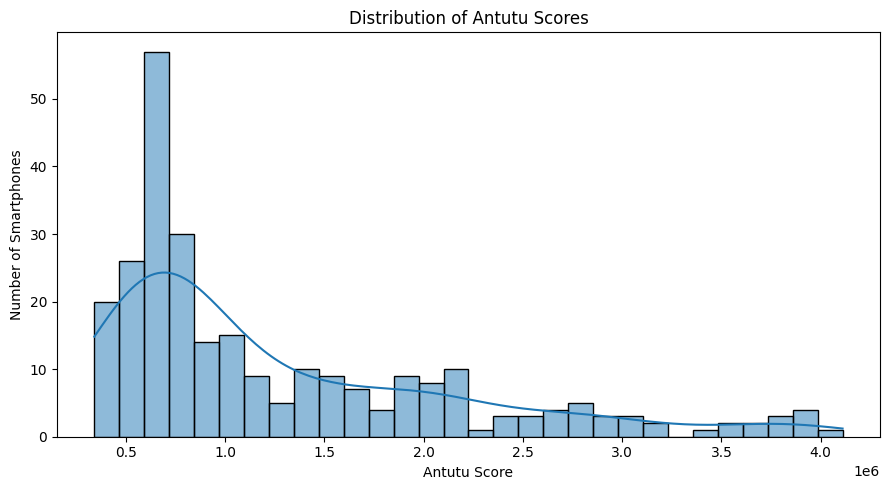

In [16]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=phones,
    x="antutu",
    bins=30,
    kde=True
)

plt.title("Distribution of Antutu Scores")
plt.xlabel("Antutu Score")
plt.ylabel("Number of Smartphones")
plt.tight_layout()
plt.show()

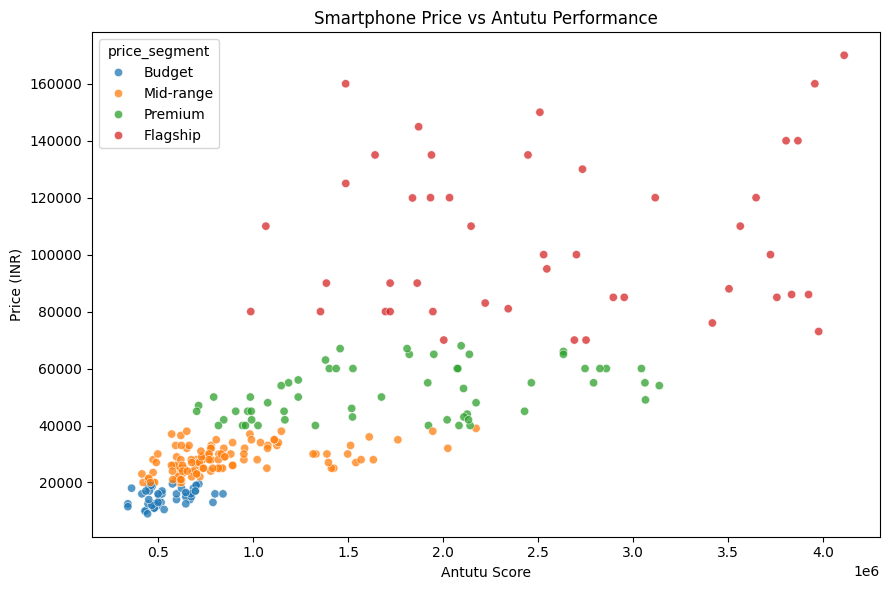

In [17]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=phones,
    x="antutu",
    y="price",
    hue="price_segment",
    alpha=0.75
)

plt.title("Smartphone Price vs Antutu Performance")
plt.xlabel("Antutu Score")
plt.ylabel("Price (INR)")
plt.tight_layout()
plt.show()

In [18]:
benchmark_columns = [
    "antutu",
    "geekbench_single",
    "geekbench_multiple"
]

phones[benchmark_columns].corr()

,antutu,geekbench_single,geekbench_multiple
antutu,1.000000,0.907336,0.954122
geekbench_single,0.907336,1.000000,0.970581
geekbench_multiple,0.954122,0.970581,1.000000


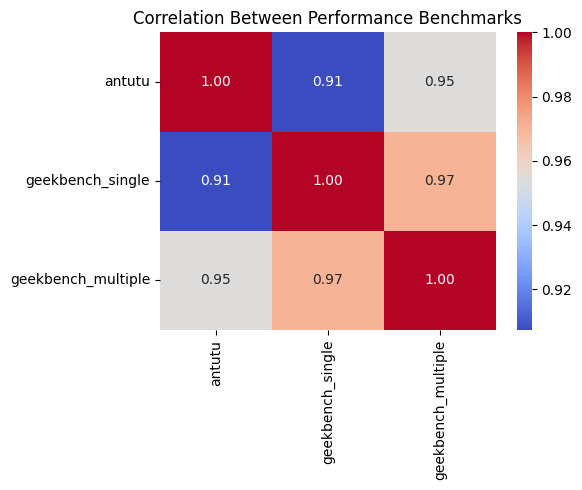

In [19]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    phones[benchmark_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Performance Benchmarks")
plt.tight_layout()
plt.show()

In [20]:
phones.groupby("fab")["antutu"].agg(
    ["count", "median", "mean"]
).sort_index()

,count,median,mean
fab,,,
2,2,3310005.0,3.310005e+06
3,54,2632918.5,2.589872e+06
4,150,892500.0,1.090590e+06
5,4,473905.0,4.675850e+05
6,60,504235.0,5.357849e+05


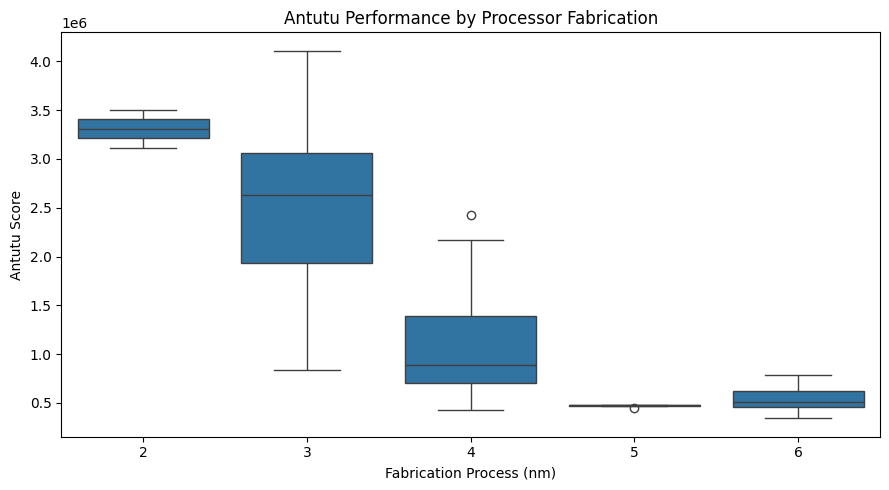

In [21]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=phones,
    x="fab",
    y="antutu"
)

plt.title("Antutu Performance by Processor Fabrication")
plt.xlabel("Fabrication Process (nm)")
plt.ylabel("Antutu Score")
plt.tight_layout()
plt.show()

## 4. Battery and charging analysis

In [22]:
phones[
    [
        "battery",
        "charging_speed"
    ]
].describe()

,battery,charging_speed
count,270.000000,270.000000
mean,6000.037037,59.625926
std,1184.370926,29.695056
min,3036.000000,10.000000
25%,5000.000000,33.000000
50%,6000.000000,45.000000
75%,7000.000000,80.000000
max,10001.000000,125.000000


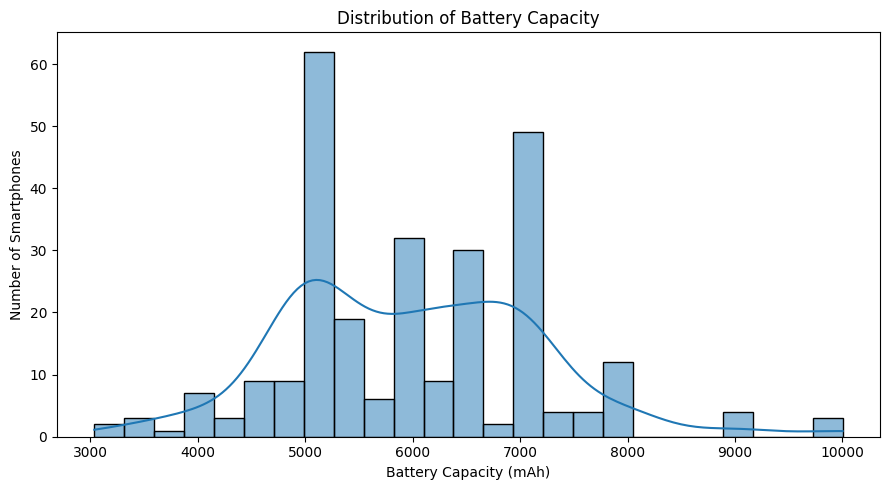

In [23]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=phones,
    x="battery",
    bins=25,
    kde=True
)

plt.title("Distribution of Battery Capacity")
plt.xlabel("Battery Capacity (mAh)")
plt.ylabel("Number of Smartphones")
plt.tight_layout()
plt.show()

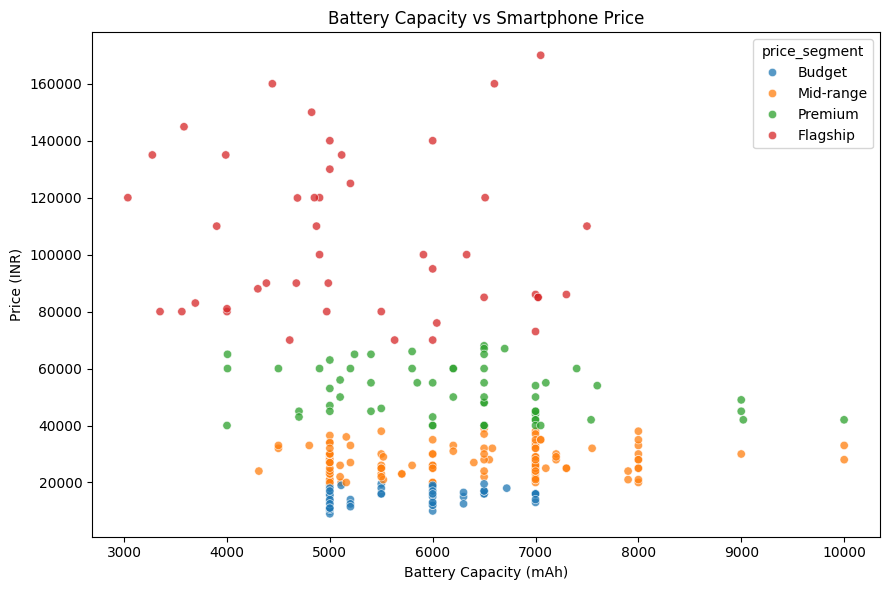

In [24]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=phones,
    x="battery",
    y="price",
    hue="price_segment",
    alpha=0.75
)

plt.title("Battery Capacity vs Smartphone Price")
plt.xlabel("Battery Capacity (mAh)")
plt.ylabel("Price (INR)")
plt.tight_layout()
plt.show()

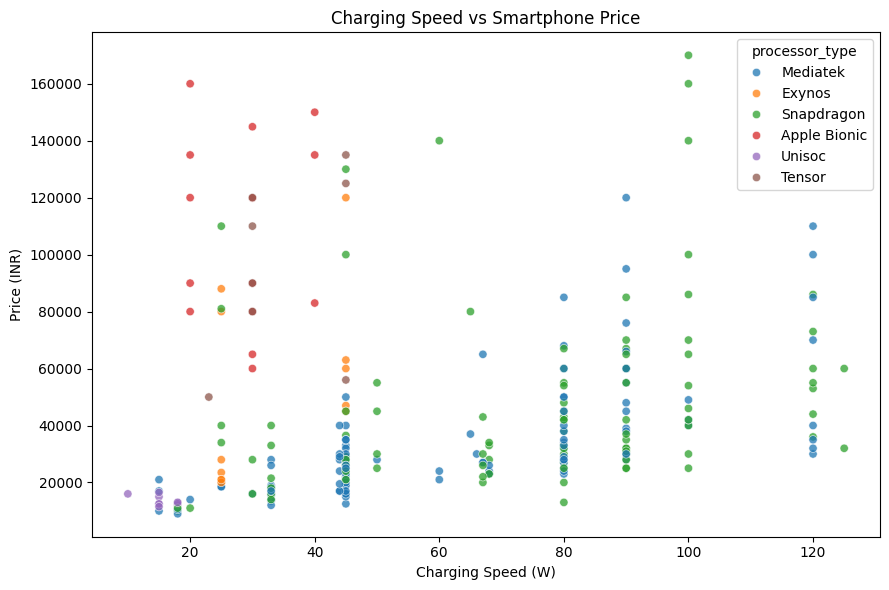

In [25]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=phones,
    x="charging_speed",
    y="price",
    hue="processor_type",
    alpha=0.75
)

plt.title("Charging Speed vs Smartphone Price")
plt.xlabel("Charging Speed (W)")
plt.ylabel("Price (INR)")
plt.tight_layout()
plt.show()

## 5. Display analysis

In [26]:
phones["display_type"].value_counts()

display_type
Amoled     213
IPS LCD     57
Name: count, dtype: int64

In [27]:
display_price = (
    phones
    .groupby("display_type")["price"]
    .agg(["count", "median", "mean"])
    .sort_values(
        "median",
        ascending=False
    )
)

display_price

,count,median,mean
display_type,,,
Amoled,213,38000.0,50236.150235
IPS LCD,57,17000.0,18543.859649


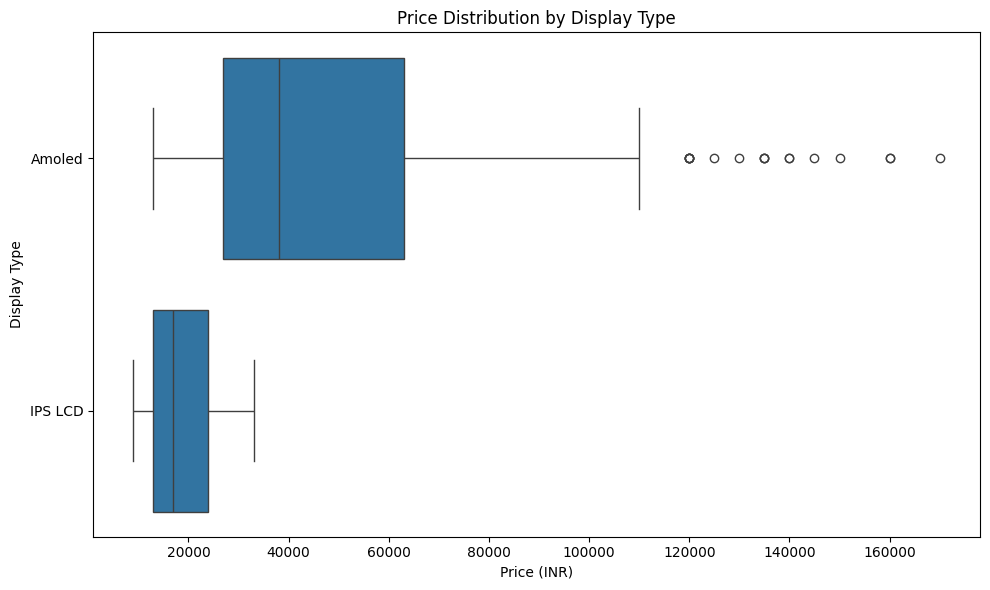

In [28]:
valid_display_types = (
    phones["display_type"]
    .value_counts()
    .loc[lambda x: x >= 5]
    .index
)

display_subset = phones[
    phones["display_type"].isin(
        valid_display_types
    )
]

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=display_subset,
    x="price",
    y="display_type"
)

plt.title("Price Distribution by Display Type")
plt.xlabel("Price (INR)")
plt.ylabel("Display Type")
plt.tight_layout()
plt.show()

In [29]:
refresh_summary = (
    phones
    .groupby("refresh_rate")
    .agg(
        phone_count=("name", "count"),
        median_price=("price", "median"),
        median_antutu=("antutu", "median")
    )
    .sort_index()
)

refresh_summary

,phone_count,median_price,median_antutu
refresh_rate,,,
60,6,80000.0,1561132.0
90,5,20000.0,473905.0
120,200,30000.0,835943.5
144,55,32000.0,848473.0
165,4,60000.0,2950992.5


## 6. Camera hardware analysis

Megapixel values represent camera hardware specifications and should not be interpreted
as direct measures of real-world image quality.

In [30]:
phones[
    [
        "main",
        "front",
        "camera_number",
        "useful_camera_number"
    ]
].describe()

,main,front,camera_number,useful_camera_number
count,270.000000,270.000000,270.000000,270.000000
mean,59.240741,23.862963,2.370370,2.007407
std,37.043697,14.804228,0.636449,0.808839
min,13.000000,5.000000,1.000000,1.000000
25%,50.000000,12.000000,2.000000,1.000000
50%,50.000000,16.000000,2.000000,2.000000
75%,50.000000,32.000000,3.000000,3.000000
max,200.000000,50.000000,4.000000,4.000000


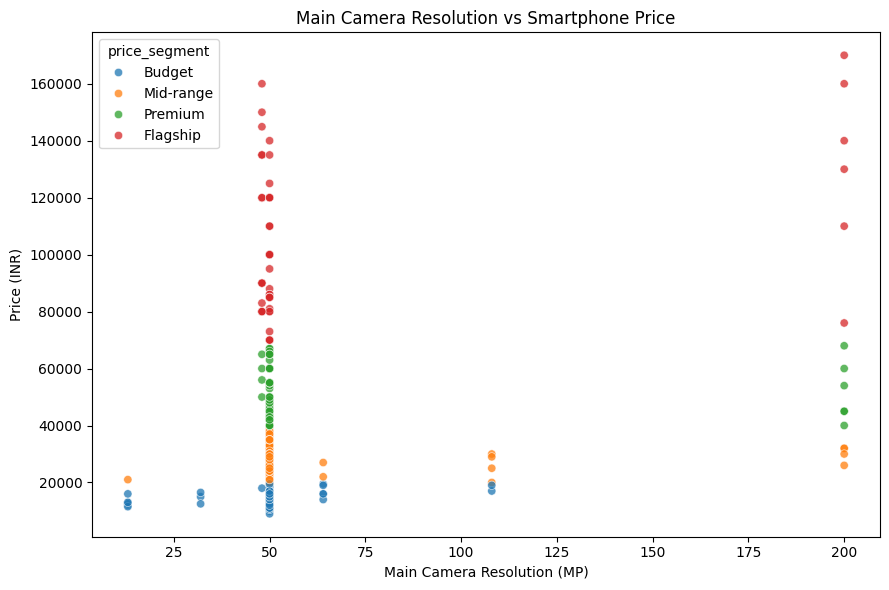

In [31]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=phones,
    x="main",
    y="price",
    hue="price_segment",
    alpha=0.75
)

plt.title("Main Camera Resolution vs Smartphone Price")
plt.xlabel("Main Camera Resolution (MP)")
plt.ylabel("Price (INR)")
plt.tight_layout()
plt.show()

In [32]:
phones["has_ultrawide"].value_counts()

has_ultrawide
True     180
False     90
Name: count, dtype: int64

In [33]:
phones.groupby(
    "has_ultrawide"
)["price"].agg(
    ["count", "median", "mean"]
)

,count,median,mean
has_ultrawide,,,
False,90,21000.0,23738.888889
True,180,40000.0,53448.888889


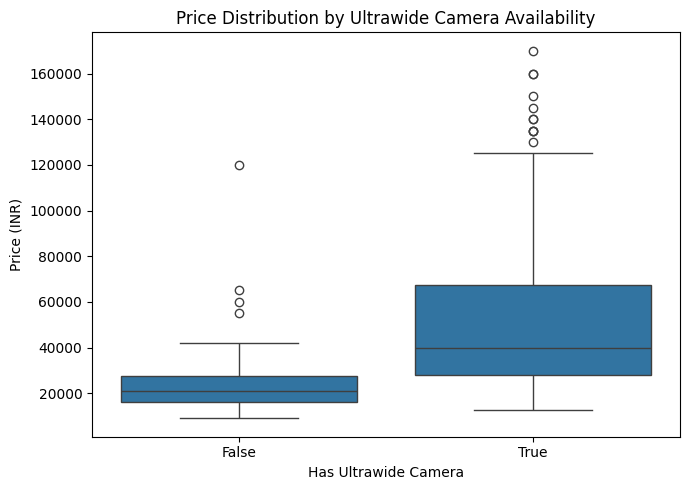

In [34]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=phones,
    x="has_ultrawide",
    y="price"
)

plt.title("Price Distribution by Ultrawide Camera Availability")
plt.xlabel("Has Ultrawide Camera")
plt.ylabel("Price (INR)")
plt.tight_layout()
plt.show()

## 7. Correlation analysis

In [35]:
correlation_features = [
    "price",
    "antutu",
    "geekbench_single",
    "geekbench_multiple",
    "fab",
    "size",
    "refresh_rate",
    "hbm",
    "ppi",
    "battery",
    "charging_speed",
    "thickness",
    "weight",
    "camera_number",
    "useful_camera_number",
    "main",
    "front",
    "phone_age_days"
]

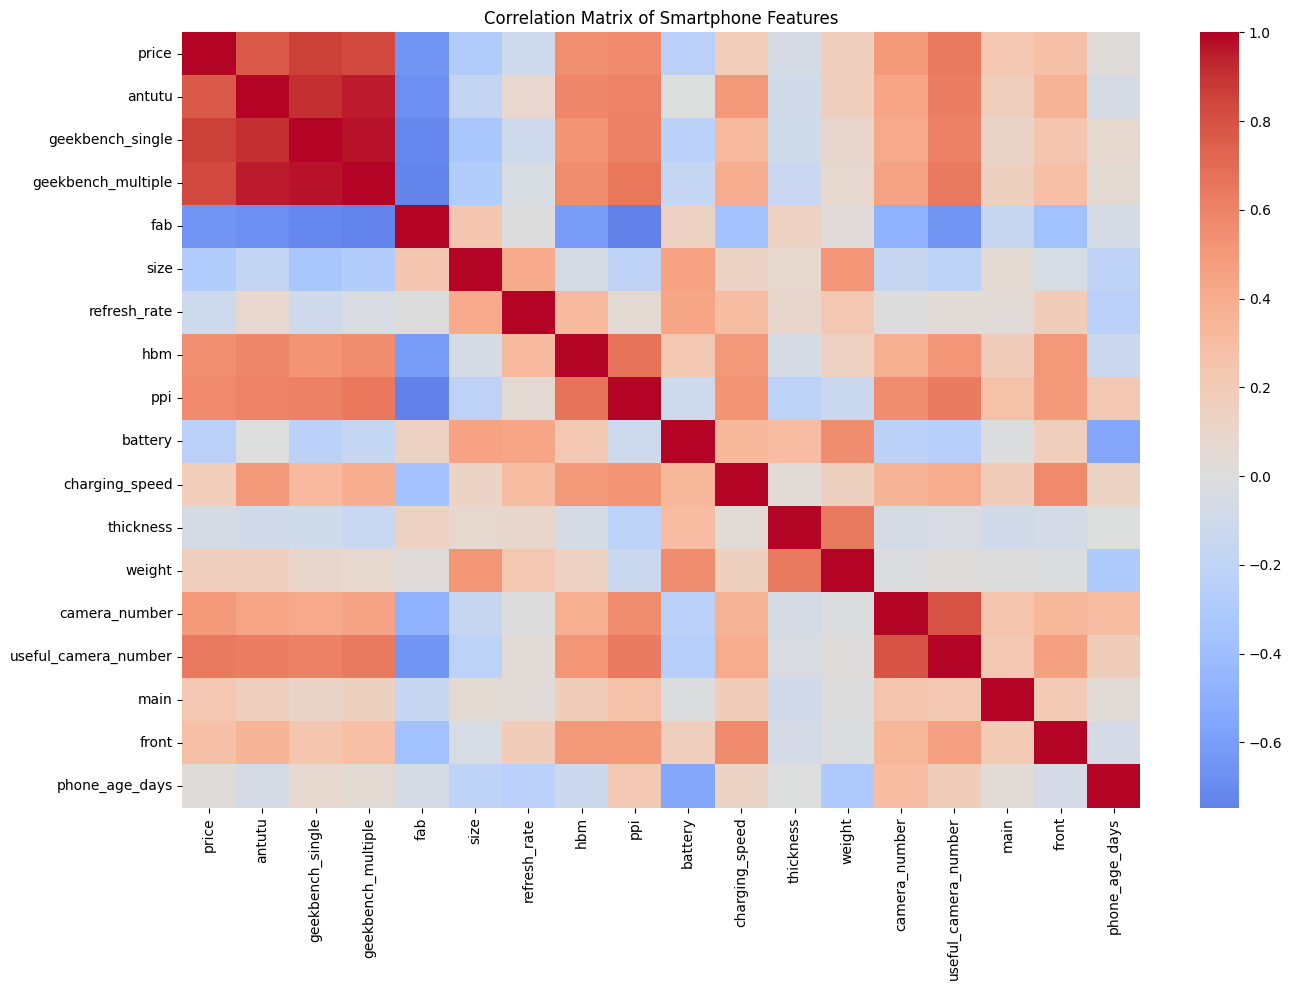

In [36]:
correlation_matrix = (
    phones[correlation_features]
    .corr()
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title(
    "Correlation Matrix of Smartphone Features"
)

plt.tight_layout()
plt.show()

In [37]:
price_correlations = (
    correlation_matrix["price"]
    .drop("price")
    .sort_values(
        key=abs,
        ascending=False
    )
)

price_correlations

geekbench_single        0.860832
geekbench_multiple      0.823176
antutu                  0.762048
fab                    -0.648221
useful_camera_number    0.644345
ppi                     0.571979
hbm                     0.548024
camera_number           0.498171
size                   -0.286261
front                   0.276465
battery                -0.240326
main                    0.232635
charging_speed          0.186428
weight                  0.169530
refresh_rate           -0.105628
thickness              -0.056561
phone_age_days          0.020825
Name: price, dtype: float64

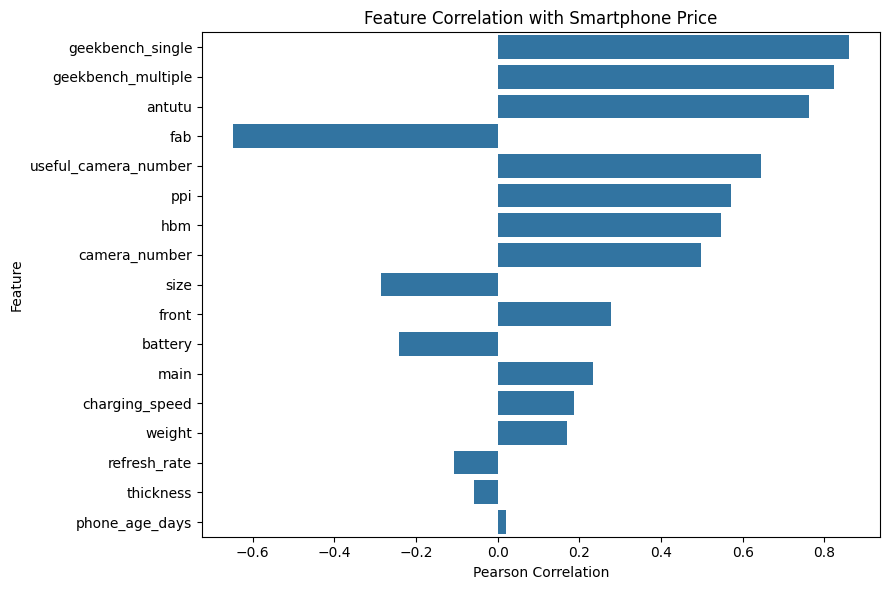

In [38]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=price_correlations.values,
    y=price_correlations.index
)

plt.title("Feature Correlation with Smartphone Price")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 8. Identifying Potential Price Outliers

In [39]:
Q1 = phones["price"].quantile(0.25)
Q3 = phones["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

price_outliers = phones[
    (phones["price"] < lower_bound)
    |
    (phones["price"] > upper_bound)
]

print("Potential price outliers:", len(price_outliers))

price_outliers[
    [
        "name",
        "brand",
        "price",
        "antutu"
    ]
].sort_values(
    "price",
    ascending=False
)

Potential price outliers: 20


,name,brand,price,antutu
130,Oppo Find X9 Ultra,Oppo,170000,4110112
37,iPhone 15 Pro Max,Apple,160000,1487203
230,Vivo X300 Ultra,Vivo,160000,3955695
45,iPhone 17 Pro Max,Apple,150000,2509041
39,iPhone 16 Pro,Apple,144900,1871052
235,Xiaomi 17 Ultra,Xiaomi,140000,3866687
27,Galaxy S26 Ultra,Samsung,140000,3804457
44,iPhone 17 Pro,Apple,135000,2446434
254,Pixel 11 Pro XL,Google,135000,1938536
36,iPhone 15 Pro,Apple,135000,1641883


## 9. Price/performance ratio


In [40]:
phones["antutu_per_1000_inr"] = (
    phones["antutu"]
    /
    (phones["price"] / 1000)
)

phones[
    [
        "name",
        "brand",
        "price",
        "antutu",
        "antutu_per_1000_inr"
    ]
].sort_values(
    "antutu_per_1000_inr",
    ascending=False
).head(15)

,name,brand,price,antutu,antutu_per_1000_inr
153,Poco F7,POCO,32000,2024751,63273.468750
161,Poco X8 Pro Max,POCO,49000,3064458,62539.959184
132,Oppo K13,Oppo,13000,789000,60692.307692
133,Oppo K13 Turbo,Oppo,28000,1632669,58309.607143
51,Iqoo 15R,IQOO,54000,3137421,58100.388889
53,Iqoo Neo 10R,IQOO,27000,1540721,57063.740741
30,Infinix GT 30 Pro,Infinix,25000,1424402,56976.080000
118,Oneplus Nord CE 5,OnePlus,25000,1412373,56494.920000
159,Poco X7 Pro,POCO,28000,1568331,56011.821429
80,Moto Edge 70 Pro,Motorola,39000,2173245,55724.230769


## Key EDA findings

After running the analysis, summarize the important observations here.

Examples of questions to answer:

1. Which brands are most represented in the dataset?
2. Is the price distribution strongly skewed?
3. Which brands are positioned primarily in premium or budget segments?
4. How strongly is Antutu associated with smartphone price?
5. How strongly are Antutu and Geekbench scores related?
6. Does battery capacity strongly influence price?
7. Does charging speed appear more related to price than battery capacity?
8. Are higher refresh rates now common outside premium phones?
9. Does megapixel count show a strong relationship with price?
10. Which numeric variables appear most related to price?
11. Are expensive statistical outliers valid flagship phones rather than erroneous records?
12. Are there obvious high-performance / low-price devices worth investigating later?